# **Autoencoder for Communications over AWGN Channel**
Usually traditional communication uses two different transmitter and receiver seperately. Autoencoder system treat to whole transmission chain as a single neural network. The encoder (transmitter) learns how to map input messages into a signal.The channel layer simulates noise, fading, or interference. The decoder (receiver) learns how to recover the original message from the noisy signal.


**System Model**
Communication starts with the messages. Each message is represented as a one-hot vector. The encoder is a neural network that converts the one-hot message into a transmitted signal x. Then output signal x which is complex generated.

The signal travels through an Additive White Gaussian \[
y = x + noise\]

where:

- **x** = transmitted signal
- **noise** = random Gaussian disturbance added by the channel
- **y** = received noisy signal

The AWGN channel models the effect of thermal noise and other random disturbances that occur during signal transmission. The receiver must recover the original message from the noisy received signal.

Receiver (Decoder)
The decoder is another neural network. It receives the noisy signal y and tries to determine which message was originally sent.

Estimated Message (
m
^
)
The final decision is made using argmax, which selects the position with the highest probability.


Import files

In [ ]:
from __future__ import print_function, division

import torch
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import argparse
import matplotlib.pyplot as plt
from torch import nn

Block Error Rate (BLER), which measures the percentage of data blocks that were decoded incorrectly. This is helpful in communication system for evaluate the reliability of channel.
$$BLER = \frac{\text{Number of erroneous blocks}}{\text{Total number of transmitted blocks}}$$

In [ ]:
def compute_BLER(x, y):
    sh = x.shape
    p = sh[0]
    ber = 0
    for i in range(p):
        # Add the lines to evaluate the count wrongly decoded blocks
        if np.argmax(x[i]) != np.argmax(y[i]):
            ber = ber + 1
        # TODO
    return ber / p

**Transmitter**
Unlike traditional communication system, transmitter of autoencoder all the functions such as souce encoder, channel encoder and modulator re learned jointly by a neural network. This converts an input message into a compact signal representation suitable for transmission over a noisy channel. The transmitter automatically optimizes this mapping during training to make the transmitted signal robust against channel noise. The output of the transmitter is a latent vector that represents the encoded message and is sent through the AWGN channel, where noise is added.

**One-Hot ($M$)** $\downarrow$
**Linear ($M \rightarrow M$)** $\downarrow$
**ReLU** $\downarrow$
**Linear ($M \rightarrow 2^n$)** $\downarrow$
**Power Normalization**

In [ ]:
class Transmitter(nn.Module): #nn for transmitter
    def __init__(self, enc_input, latent_dim):#enc_input=16 ,latent_dim (hidden layer)=8
        '''
        Initialize the discriminator.
        '''
        super(Transmitter, self).__init__()
        # Design the architecture
        self.main = nn.Sequential(
        nn.Linear(enc_input, enc_input), ##Fully connected (Dense) layer.
        nn.ReLU(), #Activation function.
        nn.Linear(enc_input,latent_dim),
        #nn.Sigmoid() #converts any input value into a number between 0 and 1.
         )
    def forward(self, input_tensor):
        return self.main(input_tensor)

**Receiver**
The receiver in an Autoencoder-AWGN communication system acts as a neural network decoder that reconstructs the original message from the noisy signal received through the channel. The receiver processes noisy input through a series of fully connected layers and activation functions to extract meaningful features and identify the most likely transmitted message. The final layer uses a Softmax activation function to generate probabilities for all possible messages, and the message with the highest probability is selected as the estimated output.

$$y(2n) \xrightarrow{\quad} \text{Linear}(2n, M) \xrightarrow{\quad} \text{ReLU} \xrightarrow{\quad} \text{Linear}(M, M) \xrightarrow{\quad} \text{Softmax}$$

In [ ]:
class Receiver(nn.Module):
    def __init__(self, enc_input, latent_dim):
        '''
        Initialize the discriminator.
        '''
        super(Receiver, self).__init__()

        # Design the architecture
        # TODO
        self.main = nn.Sequential(
        nn.Linear(latent_dim, enc_input),
        nn.ReLU(),
        nn.Linear(enc_input, enc_input),
        nn.Softmax(dim=1)
        )
    def forward(self, input_tensor):
        return self.main(input_tensor)

**Autoencoder-based communication system**
the encoded signal is normalized to ensure that its average power is equal to one, which satisfies the communication system's power constraint and enables fair performance evaluation. The normalized signal is then passed through an Additive White Gaussian Noise (AWGN) channel, where random Gaussian noise with variance determined by the parameter eps is added to simulate real-world transmission impairments. The forward() function returns three outputs: the encoded signal generated by the transmitter, the noisy channel output after AWGN corruption, and the decoded message produced by the receiver. In here it created neural network for the system.

In [ ]:
class AE(nn.Module):
    def __init__(self, enc_input, latent_dim, eps):
        '''
        Initialize the discriminator.
        '''
        super(AE, self).__init__()
        # Autoencoder quantities
        self.enc_input=enc_input
        self.latent_dim=latent_dim
        self.eps=eps # noise std deviation σ
        # Transmitter
        self.transmitter = Transmitter(enc_input, latent_dim)
        self.receiver = Receiver(enc_input, latent_dim)

    def forward(self, input_tensor):
        # pay attention, "encoded" must have average power equal to 1
        # TODO
        encoded = self.transmitter(input_tensor)
        #power nomalization
        encoded = encoded / torch.sqrt(torch.mean(encoded**2, dim=1, keepdim=True))
        #AWGN channel: add Gaussian noise
        noise = torch.randn_like(encoded) * self.eps
        ch_output = encoded + noise
        #decode
        decoded = self.receiver(ch_output)
        return encoded, ch_output, decoded


**AutoEncoder Class**
This class plan to  sets up all the parameters, builds the model, and runs training and testing.

The network is trained **end-to-end** using cross-entropy loss, with the Additive White Gaussian Noise (AWGN) channel layer integrated directly inside the forward pass. This setup enables backpropagation to flow through the channel, allowing the network to update both the encoder and decoder simultaneously.

The **Adam optimizer** is used with a batch of randomly sampled one-hot messages each epoch.

#### Cross-Entropy Loss Function
$$\mathcal{L} = -\sum_{m} p(m) \log \hat{p}(m)$$

The channel noise effectively acts as a **stochastic regularizer** during training. It forces the encoder to learn a robust, optimized signal constellation that remains distinct and separable even under noisy conditions.

Actual SNR is:-20
Starting training for 2000 epochs...
Actual SNR is:-19
Starting training for 2000 epochs...
Actual SNR is:-18
Starting training for 2000 epochs...
Actual SNR is:-17
Starting training for 2000 epochs...
Actual SNR is:-16
Starting training for 2000 epochs...
Actual SNR is:-15
Starting training for 2000 epochs...
Actual SNR is:-14
Starting training for 2000 epochs...
Actual SNR is:-13
Starting training for 2000 epochs...
Actual SNR is:-12
Starting training for 2000 epochs...
Actual SNR is:-11
Starting training for 2000 epochs...
Actual SNR is:-10
Starting training for 2000 epochs...
Actual SNR is:-9
Starting training for 2000 epochs...
Actual SNR is:-8
Starting training for 2000 epochs...
Actual SNR is:-7
Starting training for 2000 epochs...
Actual SNR is:-6
Starting training for 2000 epochs...
Actual SNR is:-5
Starting training for 2000 epochs...
Actual SNR is:-4
Starting training for 2000 epochs...
Actual SNR is:-3
Starting training for 2000 epochs...
Actual SNR is:-2


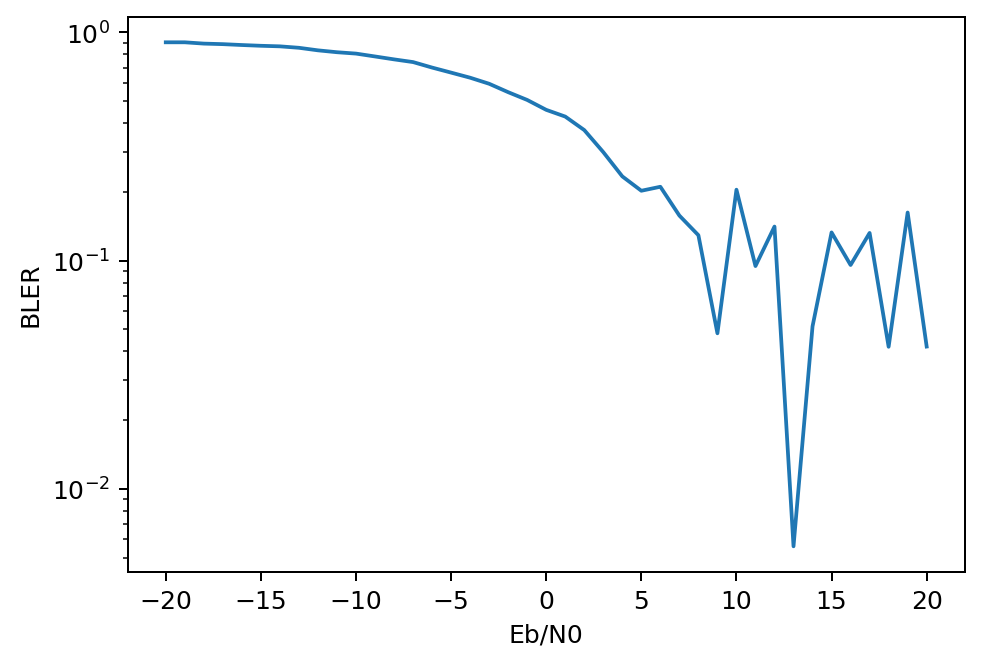

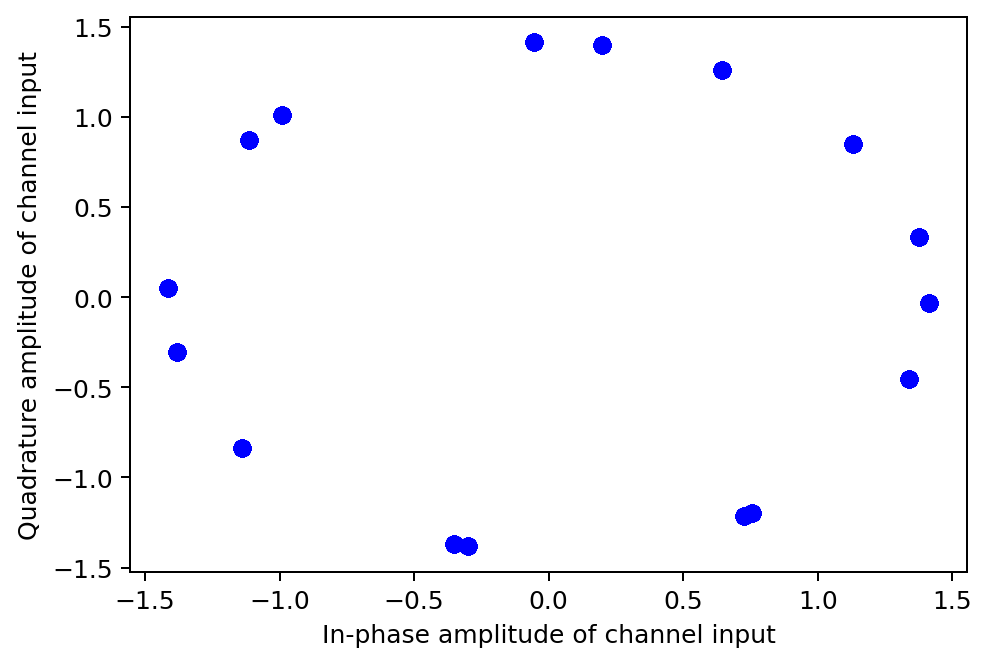

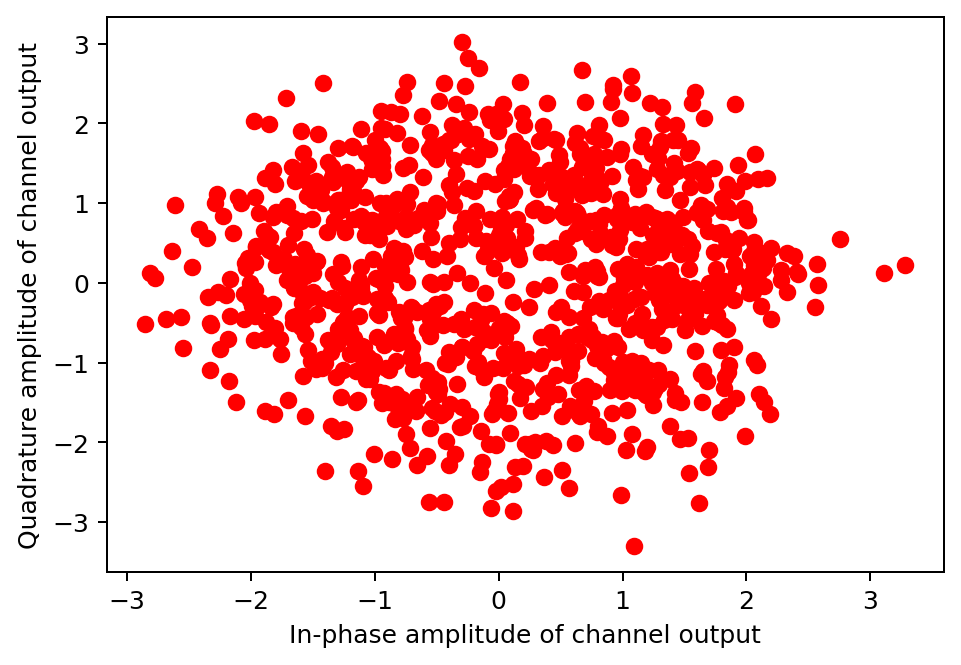

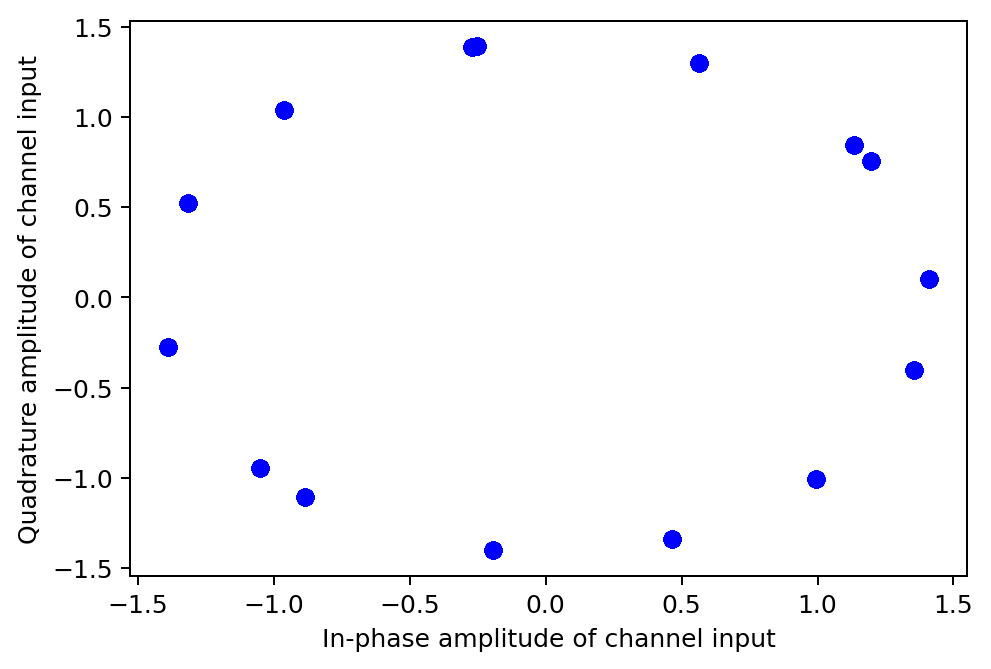

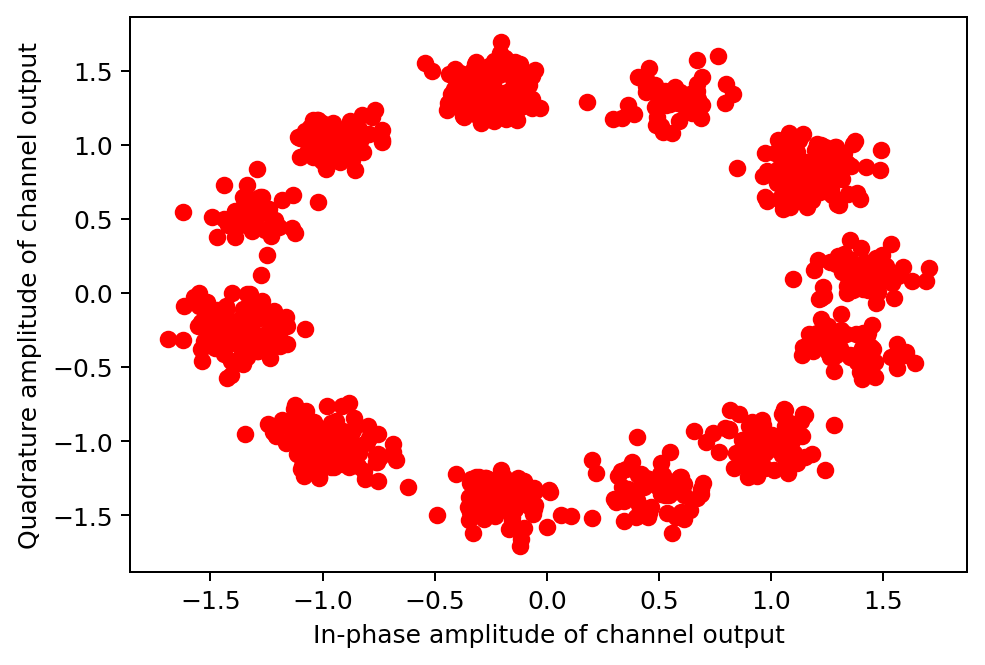

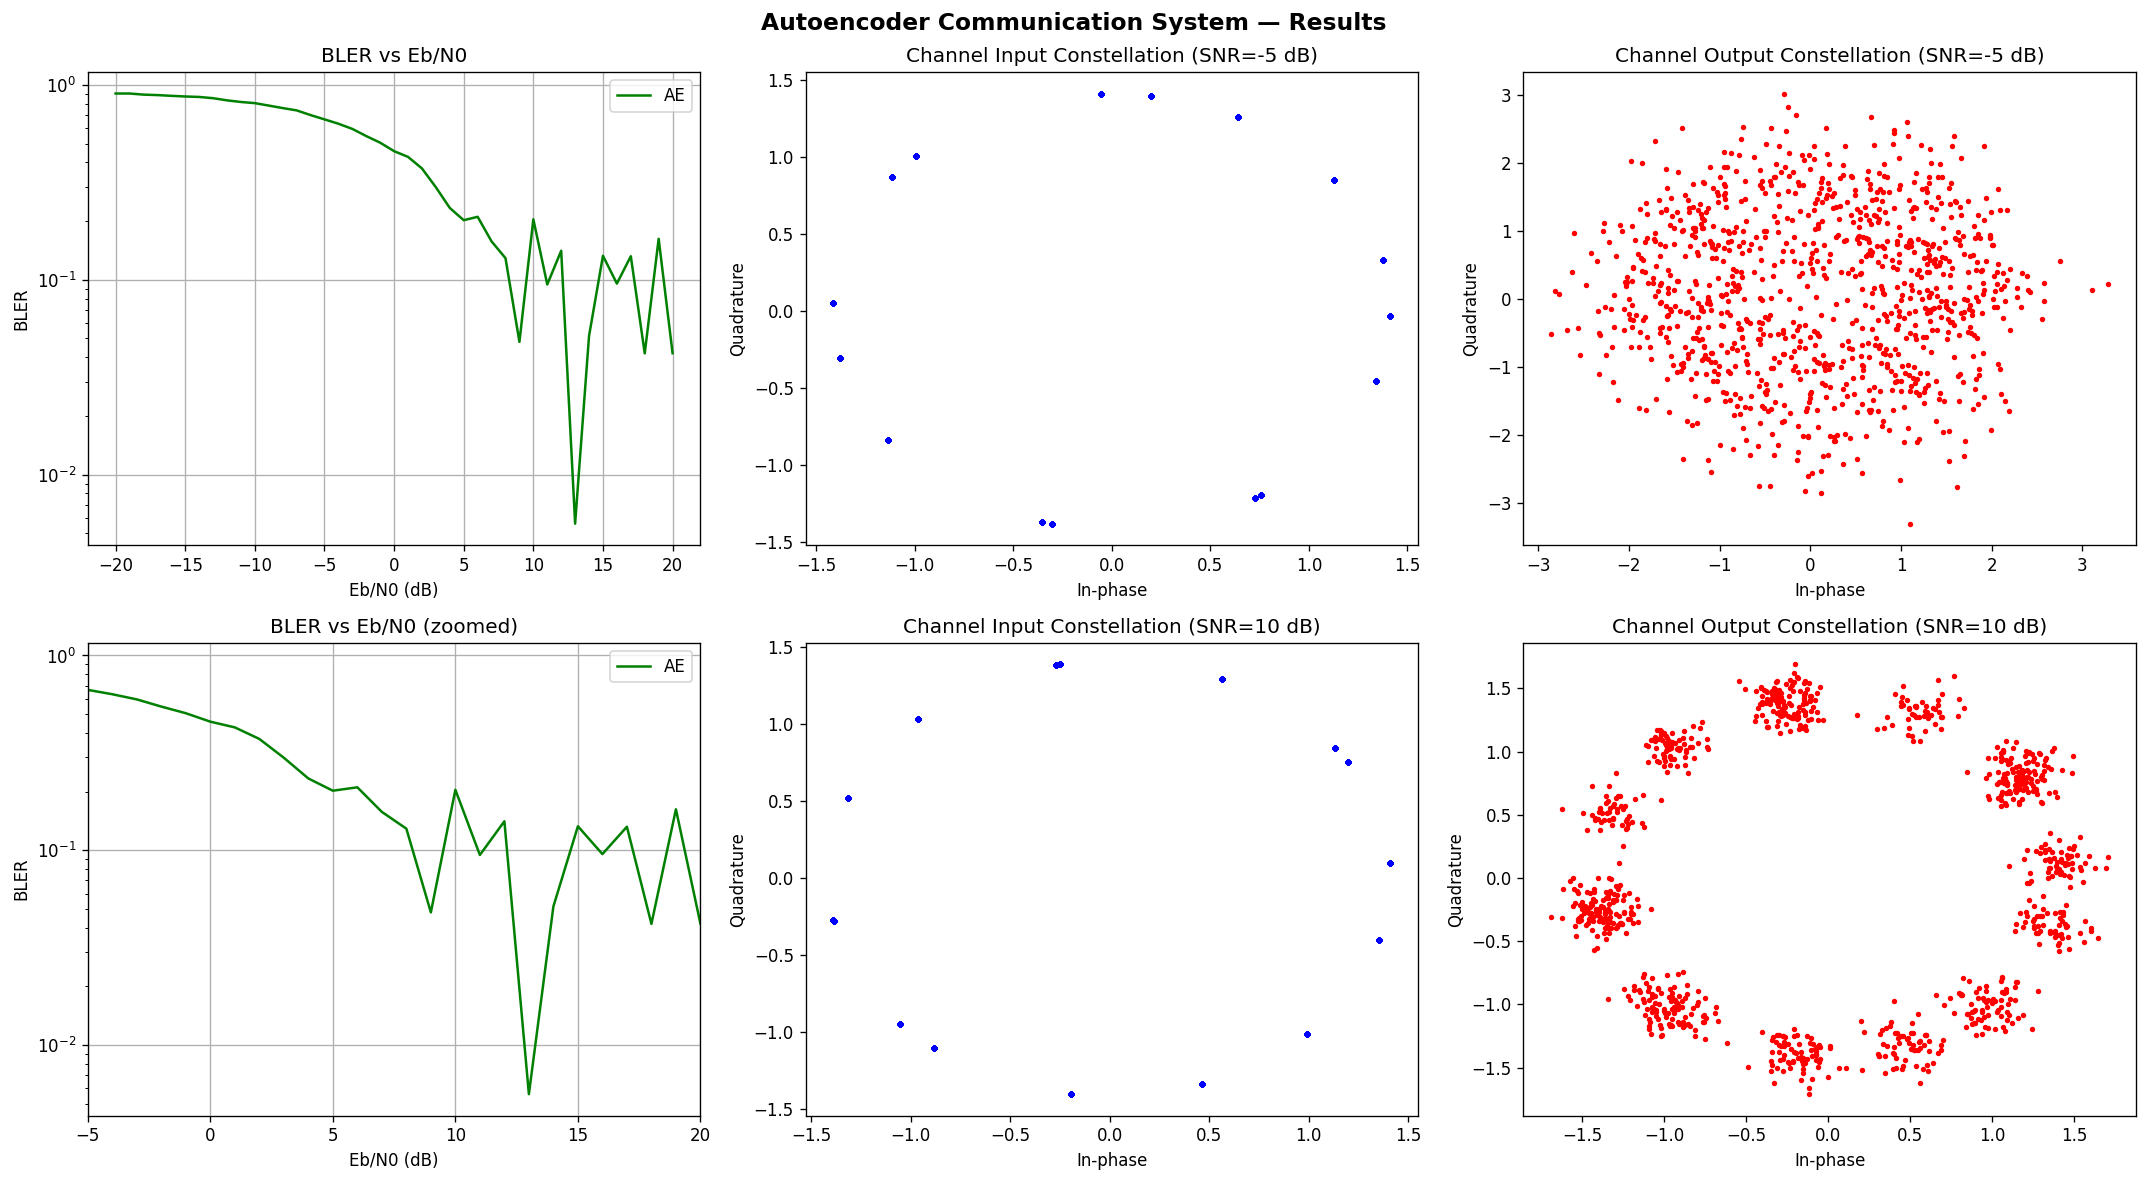

In [ ]:
import numpy as np
class AutoEncoder():
    def __init__(self, k, n, EbN0):
        self.k = k  # k parameter, log2(M)
        self.enc_input = pow(2, self.k)  # M parameter = 2^k
        self.n = 2 * n  # to count for complex symbols

        R = self.k / n  # communication rate
        self.latent_dim = self.n  # channel uses
        self.EbN0 = EbN0  # energy bit over noise power

         # Convert Eb/N0 from dB to linear scale
        EbN0_linear = 10 ** (EbN0 / 10.0)

        # Noise power
        self.N =  1 / (2 * R * EbN0_linear)
        # Noise std deviation
        self.eps = np.sqrt(self.N)
        # Autoencoder
        self.AE = AE(self.enc_input, self.latent_dim, self.eps)
        # Optimizer
        self.optimizer = optim.Adam(self.AE.parameters(), lr=1e-3)
        # Loss Function
        self.loss_fn = nn.NLLLoss()
        # Add scheduler in AutoEncoder.__init__:
        #self.optimizer = optim.Adam(self.AE.parameters(), lr=1e-3)
        self.scheduler = torch.optim.lr_scheduler.StepLR(
            self.optimizer, step_size=500, gamma=0.5
        )

        # Add in fit() loop after optimizer.step():
        #self.scheduler.step()

    def fit(self, epochs, batch_size=128):
        # Find a way to defined s_in as one-hot vectors where all elements are equal to zero except one at the position representing the number.
        # TODO
        eye=torch.eye(self.enc_input)
        M=self.enc_input
        print(f"Starting training for {epochs} epochs...")


        for epoch in range(epochs):
            # Obtain random indices to extract batch
            # TODO
            idx = torch.randint(0, M, (batch_size,))  # integer class labels
             # Select corresponding one-hot vectors
            s_in = eye[idx]  # shape: (batch_size, M)
             # Forward pass
            self.optimizer.zero_grad()
            _, _, s_out = self.AE(s_in)
                # Loss: NLLLoss needs log-probs and integer targets
            loss = self.loss_fn(torch.log(s_out), idx)

            # Backprop + parameter update
            loss.backward()
            self.optimizer.step()
            self.scheduler.step()
            # Train autoencoder
            # TODO


    def test(self, test_size):
        # As for the training process, define s_in as the one-hot input of the autoencoder
        # TODO

        # Find a way to defined s_in as one-hot vectors where all elements are equal to zero except one at the position representing the number.
        #calculate all m-one hot vector as rows of the identity matrix
        eye=torch.eye(self.enc_input)
        M=self.enc_input

        # extract the channel input, output, and the reconstructed s_in
        idx=torch.randint(0, M, (test_size,))
        s_in=eye[idx]

        # Forward pass without gradient tracking (inference only)
        with torch.no_grad():
            x, y, s_out = self.AE(s_in)

        # compute the block-error-rate
        bler = compute_BLER(s_in.detach().numpy(), s_out.detach().numpy())

        return bler, s_in, x, y, s_out


if __name__ == '__main__':

    #parser = argparse.ArgumentParser()
    #parser.add_argument('--batch_size', help='Number of data samples to train on at once', default=128)
    #parser.add_argument('--epochs', help='Number of epochs to train for', default=500)
    #parser.add_argument('--test_size', help='Number of data samples for testing', default=10000)
    #args = parser.parse_args()
    epochs = 2000
    batch_size = 128
    test_size = 10000

    k = 4
    n = 1
    #epochs = int(args.epochs)
    #batch_size = int(args.batch_size)
    #test_size = int(args.test_size)

    k = 4  # entropy of the source, block-size
    n = 1  # channel uses
    SNR_dB = range(-20,21)   # training range

    bler_total = np.zeros((len(SNR_dB), 1))
    x_total = np.zeros((len(SNR_dB), test_size, 2 * n))
    y_total = np.zeros((len(SNR_dB), test_size, 2 * n))

    j = 0
    for SNR in SNR_dB:
        print(f'Actual SNR is:{SNR}')
        # Initialize dDIME
        ae = AutoEncoder(k, n, SNR)
        # Train
        ae.fit(epochs=epochs, batch_size=batch_size)
        # Test
        bler, _, x, y, _ = ae.test(test_size=test_size)
        bler_total[j, 0] = bler
        x_total[j] = x.detach().numpy()
        y_total[j] = y.detach().numpy()
        del ae
        j = j + 1

    # BLER plot in logarithmic scale
    plt.figure(figsize=(6, 4), dpi=180)
    plt.semilogy(SNR_dB, bler_total, label='AE')

    plt.xlabel("Eb/N0")
    plt.ylabel("BLER")
    plt.show()

    # Channel input constellation diagram, only 1000 points
    SNR_to_plot = -5
    plt.figure(figsize=(6, 4), dpi=180)
    plt.scatter(x_total[SNR_to_plot - SNR_dB[0], 0:1000, 0], x_total[SNR_to_plot - SNR_dB[0], 0:1000, 1], c='blue')
    plt.xlabel("In-phase amplitude of channel input")
    plt.ylabel("Quadrature amplitude of channel input")
    plt.show()

    # Channel output constellation diagram
    SNR_to_plot = -5
    plt.figure(figsize=(6, 4), dpi=180)
    plt.scatter(y_total[SNR_to_plot - SNR_dB[0], 0:1000, 0], y_total[SNR_to_plot - SNR_dB[0], 0:1000, 1], c='red')
    plt.xlabel("In-phase amplitude of channel output")
    plt.ylabel("Quadrature amplitude of channel output")
    plt.show()

    # Channel input constellation diagram, only 1000 points
    SNR_to_plot = 10
    plt.figure(figsize=(6, 4), dpi=180)
    plt.scatter(x_total[SNR_to_plot - SNR_dB[0], 0:1000, 0], x_total[SNR_to_plot - SNR_dB[0], 0:1000, 1], c='blue')
    plt.xlabel("In-phase amplitude of channel input")
    plt.ylabel("Quadrature amplitude of channel input")
    plt.show()

    # Channel output constellation diagram
    SNR_to_plot = 10
    plt.figure(figsize=(6, 4), dpi=180)
    plt.scatter(y_total[SNR_to_plot - SNR_dB[0], 0:1000, 0], y_total[SNR_to_plot - SNR_dB[0], 0:1000, 1], c='red')
    plt.xlabel("In-phase amplitude of channel output")
    plt.ylabel("Quadrature amplitude of channel output")
    plt.show()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=120)

# 1. BLER curve
axes[0, 0].semilogy(SNR_dB, bler_total, label='AE', color='green')
axes[0, 0].set_xlabel("Eb/N0 (dB)")
axes[0, 0].set_ylabel("BLER")
axes[0, 0].set_title("BLER vs Eb/N0")
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. Constellation input at SNR = -5
SNR_to_plot = -5
idx = SNR_to_plot - SNR_dB[0]
axes[0, 1].scatter(x_total[idx, 0:1000, 0], x_total[idx, 0:1000, 1], c='blue', s=5)
axes[0, 1].set_xlabel("In-phase")
axes[0, 1].set_ylabel("Quadrature")
axes[0, 1].set_title(f"Channel Input Constellation (SNR={SNR_to_plot} dB)")

# 3. Constellation output at SNR = -5
axes[0, 2].scatter(y_total[idx, 0:1000, 0], y_total[idx, 0:1000, 1], c='red', s=5)
axes[0, 2].set_xlabel("In-phase")
axes[0, 2].set_ylabel("Quadrature")
axes[0, 2].set_title(f"Channel Output Constellation (SNR={SNR_to_plot} dB)")

# 4. Empty or reuse — here we add a zoomed BLER
axes[1, 0].semilogy(SNR_dB, bler_total, label='AE', color='green')
axes[1, 0].set_xlim([-5, 20])
axes[1, 0].set_xlabel("Eb/N0 (dB)")
axes[1, 0].set_ylabel("BLER")
axes[1, 0].set_title("BLER vs Eb/N0 (zoomed)")
axes[1, 0].legend()
axes[1, 0].grid(True)

# 5. Constellation input at SNR = 10
SNR_to_plot = 10
idx = SNR_to_plot - SNR_dB[0]
axes[1, 1].scatter(x_total[idx, 0:1000, 0], x_total[idx, 0:1000, 1], c='blue', s=5)
axes[1, 1].set_xlabel("In-phase")
axes[1, 1].set_ylabel("Quadrature")
axes[1, 1].set_title(f"Channel Input Constellation (SNR={SNR_to_plot} dB)")

# 6. Constellation output at SNR = 10
axes[1, 2].scatter(y_total[idx, 0:1000, 0], y_total[idx, 0:1000, 1], c='red', s=5)
axes[1, 2].set_xlabel("In-phase")
axes[1, 2].set_ylabel("Quadrature")
axes[1, 2].set_title(f"Channel Output Constellation (SNR={SNR_to_plot} dB)")

plt.suptitle("Autoencoder Communication System — Results", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("ae_results.png", dpi=150, bbox_inches='tight')
plt.show()

**Conclusion**
The graphs stated that neural network autoencoder can learn an end-to-end communication system over an AWGN channel without any specific channel design.

BLER curve explains how communication system works when signal quality improves. At very low SNR values (around −20 dB), the noise is much stronger than the transmitted signal, so the receiver struggles to identify the correct message and most messages are decoded incorrectly.As the SNR increases, the signal becomes clearer and the BLER decreases steadily. By around +13 dB, only a very small number of messages are decoded incorrectly. this highlighted that autoencoder learn sucessfully.

The constellation plots show what the autoencoder learned during training. The points are evenly distributed in a circular pattern, which is very similar to what is considered efficient for communication over an AWGN channel. this means autoencoder can be findout good signal presentation using training.

According to constellation plots, At −5 dB, the received points are heavily scattered because the noise is strong, making it difficult for the receiver to distinguish between different messages. it means it observe high BLER during low SNR values. At +10 dB, the received points form clear and separate clusters because the noise is much lower. so, receiver can correctly findout transmitted signal.